In [1]:
import numpy as np

from matplotlib import pyplot as plt

import torch
import ili
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner 
from ili.validation.metrics import PosteriorCoverage, PlotSinglePosterior

import pickle
import json

/mnt/home/fmaion/packages/ltu-ili/.ltu_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/home/fmaion/packages/ltu-ili/.ltu_venv/lib/python3.10/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
def load_training_summaries(name):    
    basepath = '/mnt/ceph/users/fmaion/projects/bias_priors/training_results/'+name+'/'
    
    with open(basepath+name+'_posterior.pkl', 'rb') as f:
        # This loads the object exactly as it was saved
        posterior_ensemble = pickle.load(f)
    
    with open(basepath+name+'_summary.json', 'rb') as f:
        summaries = json.load(f)

    return posterior_ensemble, summaries

In [6]:
posterior, summaries = load_training_summaries('bias_NPE')
posterior_int, summaries_int = load_training_summaries('bias_NPE_intermediate_GEM')
posterior_bs_v2, summaries_bs_v2 = load_training_summaries('bias_NPE_large_bs_v2')
posterior_log_bs_v2, summaries_log_bs_v2 = load_training_summaries('bias_NPE_large_log_bs_v2')
posterior_log_11_bs_v2, summaries_log_11_bs_v2 = load_training_summaries('bias_NPE_large_log_11_bs_v2')

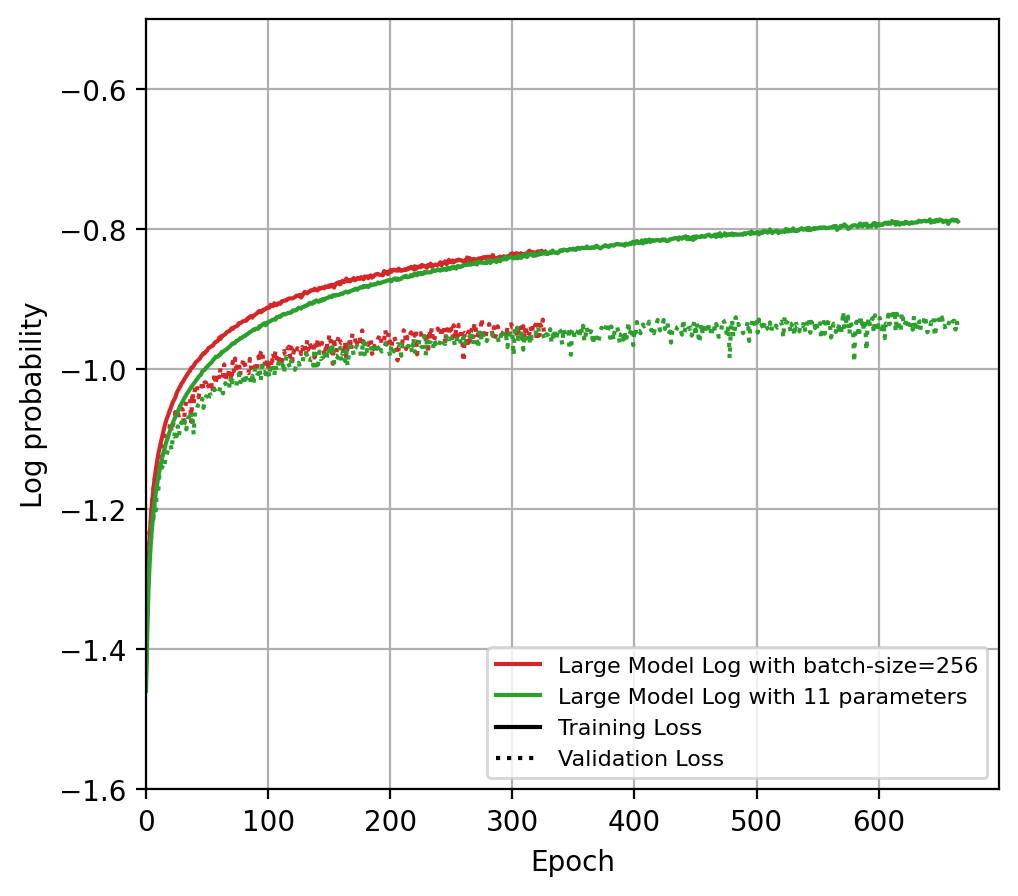

In [8]:
# plot train/validation loss
fig, ax = plt.subplots(1, 1, figsize=(5.5, 5), dpi=200)

# Large Model Log + small batch-size
ax.plot(np.array(summaries_log_bs_v2[0]['training_log_probs']),
        ls='-', label="Large Model Log with batch-size=256", color="C3")
ax.plot(np.array(summaries_log_bs_v2[0]['validation_log_probs']),
        ls=':', color="C3")

# Large Model Log + Reduced parameter-size
ax.plot(np.array(summaries_log_11_bs_v2[0]['training_log_probs']),
        ls='-', label="Large Model Log with 11 parameters", color="C2")
ax.plot(np.array(summaries_log_11_bs_v2[0]['validation_log_probs']),
        ls=':', color="C2")

ax.plot(np.zeros(10), np.zeros(10), color='k', label="Training Loss")
ax.plot(np.zeros(10), np.zeros(10), color='k', ls=':', label="Validation Loss")
ax.set_ylim(-1.6,-0.5)

ax.set_xlim(0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend(fontsize=8, loc='lower right')

plt.grid()

In [ ]:
data = np.loadtxt("/mnt/ceph/users/camels/Sims/IllustrisTNG_extras/L50n512/SB35/CosmoAstroSeed_IllustrisTNG_L50n512_SB35.txt", skiprows=1,\
                 dtype={'names': ('Name', 'Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 'VariableWindVelFactor',\
                                  'RadioFeedbackReiorientationFactor', 'OmegaBaryon', 'HubbleParam', 'n_s',\
                                  'MaxSfrTimescale', 'FactorForSofterEQS', 'IMFslope', 'SNII_MinMass_Msun',\
                                  'ThermalWindFraction', 'VariableWindSpecMomentum', 'WindFreeTravelDensFac',\
                                  'MinWindVel', 'WindEnergyReductionFactor', 'WindEnergyReductionMetallicity',\
                                  'WindEnergyReductionExponent', 'WindDumpFactor', 'SeedBlackHoleMass',\
                                  'BlackHoleAccretionFactor', 'BlackHoleEddingtonFactor', 'BlackHoleFeedbackFactor',\
                                  'BlackHoleRadiativeEfficiency', 'QuasarThreshold', 'QuasarThresholdPower', 'UVBH0beta',\
                                  'UVBH0Deltaz', 'UVBHepbeta', 'UVBHepDeltaz', 'SNIa_Rate_Norm', 'SNIa_Rate_DTD_power',\
                                  'SofteningComovingType01', 'seed'),
                        'formats': ('U100', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4',\
                                   'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4',\
                                   'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4')} )

theta = np.zeros(36)
for i in range(1,36):
    theta[i-1] = data[0][i]

theta[35] = 1

In [7]:
x = np.load("/mnt/home/fmaion/storage/projects/bias_priors/training_data/x_downsampled.npy", allow_pickle=True)
theta = np.load("/mnt/home/fmaion/storage/projects/bias_priors/training_data/theta_downsampled.npy", allow_pickle=True)

In [48]:
pars = {}
for i in range(1,36):
    pars[i-1] = np.array([data[j][i] for j in range(1024)])
    ratio = np.abs( np.max(pars[i-1]) / np.min(pars[i-1]) )
    if ratio > 20:
        print("Parameter {:d} has varied by more than one order of magnitude, with min={:.3f} and max={:.3f}".format(i-1, np.min(pars[i-1]), np.max(pars[i-1])))

Parameter 14 has varied by more than one order of magnitude, with min=3.632 and max=3998.800
Parameter 15 has varied by more than one order of magnitude, with min=0.005 and max=0.500
Parameter 23 has varied by more than one order of magnitude, with min=0.100 and max=9.996
Parameter 26 has varied by more than one order of magnitude, with min=0.000 and max=0.063
Parameter 27 has varied by more than one order of magnitude, with min=0.003 and max=3.999
Parameter 28 has varied by more than one order of magnitude, with min=0.464 and max=9.986


In [67]:
log_normalize = np.array([14,15,23,26,28])